# Predicting Numerical Value

Some models predict a continuous variable. For example, can we predict a student's test score based on hours studied?

**Outcomes**:
- Interpret correlation strength and significance (p-value)
- Distinguish between statistical significance and practical importance
- Distinguish between correlation and causation
- Read a pairplot and a correlation heatmap

**Links:**

- [Data file 1](hwg_metadata.csv)
- [Data file 2](hwg_measurements.csv)
- [Correlation Simulation](correlation.html)
- [Correlation samples](correlation_samples.docx)
  - [Poll](https://docs.google.com/forms/d/e/1FAIpQLSdAzdeIGzL0F2j4xPqqmLLnq1bkcuslApHJhLw8ryXjkhHdTw/viewform?usp=publish-editor)
  - [Answers Spreadsheet](https://docs.google.com/spreadsheets/d/15DGDcSCIAMRfq71E-VJqOTNjM1knpSdsQP-Fu2rX-ZE)
- [Quizlet terms](https://quizlet.com/1127642197/ml04-predicting-numbers-flash-cards/?i=2up6jq&x=1jqt)

**Other Resources:**
- [Helpful video on correlation](https://www.youtube.com/watch?v=rijqfllOq6g)
- [Good discussion and examples of correlation](https://www.reddit.com/r/dataisbeautiful/comments/18p85yp/correlating_four_other_variables_with_a_states/?share_id=IsERBPtlNN-F0Bw9s0kSn)
- [Spurious Correlations](https://www.tylervigen.com/spurious-correlations) (funny examples of correlation without causation)

## Correlation

A simple model for predicting numerical value is *correlation*. Correlation (Pearson's *r*) measures the strength *and* direction of a **linear** relationship between two continuous variables.

Interpretation:
- Ranges from -1 to +1
  - +1 is perfect positive correlation (as one goes up, so does the other)
  - -1 is perfect negative correlation (as one goes up, the other goes down)
  - 0 is no *linear* correlation
- Strength uses the absolute value, writting as |r|.  A -0.6 is just as strong as +0.6. 

Some common rules of thumb:

| \|r\| | Strength |
|---|---|
| < 0.1 | Negligible |
| 0.1 – 0.3 | Weak |
| 0.3 – 0.5 | Moderate |
| > 0.5 | Strong |

These cutoffs are conventions. Different fields use different ones.

**Limits of correlation:**
- It only measures *straight-line* relationships. A strong curved relationship (like a U shape) can have r near 0. Always plot your data!
- A few outliers can push r up or down a lot.

Correlation is not causation! Two variables may be correlated, but that does not mean one causes the other. There may be a third variable (a *confounder*) causing both, or it may be a coincidence.

![Comic: every person who confuses correlation with causation eventually dies](every_person_who_confuses.png)

## Is the Correlation Real? (Statistical Significance)

A correlation calculated from a sample might just be a fluke. In a classical approach to statistics, we check this with a p-value.

- **Null hypothesis** is the assumption that there is no correlation in the population (r = 0).
- **p-value** is the probability of seeing a correlation *at least this strong* if the null hypothesis were true.
  - A low p-value (<= 0.05) means a result this strong would be rare if there were no real relationship, so we call it *statistically significant*.
  - A high p-value (> 0.05) means we can't rule out chance.

We use a default threshold of 0.05 for p-values, but in the real-world, this value may change. For example, in medical research, a p-value of 0.01 may be used to reduce the chance of false positives. As sample size grows, the p-value can become very small even for a weak correlation. So, we need to consider the number of variables being evaluated, and the number of rows in the sample. In general, the larger the sample size, the more likely a correlation will be statistically significant.

A correlation has both:
- **Strength** (r) is how closely the points fit a line
- **Statistical significance** (p-value) is how confident we are the correlation isn't zero

These are **different** things. With a large sample, even a tiny, useless correlation can be statistically significant. We'll see an example below.

*Looking ahead* In newer ML approaches, we will measure error by splitting our data into training and test sets. After training our model, we evaluate it on the test set. This will be covered in later modules.

## Example: Height, Weight, and Body Measurements

We'll use a dataset of about 2,000 people with their height, weight, gender, and body measurements.

In [71]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# The metadata file has 4 rows of notes before the column headers, so skip them
df_meta = pd.read_csv('hwg_metadata.csv', skiprows=4)
df_measurements = pd.read_csv('hwg_measurements.csv')

# join the two tables together on subject_id, keeping only rows that exist in both tables
df_raw = pd.merge(df_meta, df_measurements, on='subject_id', how='inner')

# Convert gender to an is_male column (1 = male, 0 = female)
df_raw['is_male'] = np.where(df_raw['gender'] == 'male', 1, 0)

# Create height_m column
df_raw['height_m'] = df_raw['height_cm'] / 100

# Create bmi column (BMI = weight / height squared)
df_raw['bmi'] = df_raw['weight_kg'] / (df_raw['height_m'] ** 2)

# Rename arm-length to match the other column names
df_raw = df_raw.rename(columns={'arm-length': 'arm_length'})

# Keep only a few columns for easier analysis
df = df_raw[['height_cm', 'is_male', 'weight_kg', 'bmi', 'arm_length']].copy()

df.head()

,height_cm,is_male,weight_kg,bmi,arm_length
0,160.00,0,92.4,36.093750,46.422310
1,175.75,0,102.8,33.281466,53.050766
2,174.80,1,106.9,34.986045,52.061996
3,181.50,1,111.8,33.938180,52.575706
4,161.60,0,93.0,35.612317,46.116558


### One Pair of Variables

`pearsonr` returns both the correlation (r) and the p-value.

In [72]:
r, p = stats.pearsonr(df['height_cm'], df['weight_kg'])

print(f"Correlation between height and weight: r = {r:.2f}")

# Very small p-values would round to 0.00, which is misleading (p is never exactly 0)
if p < 0.001:
    print("P-value: < 0.001")
else:
    print(f"P-value: {p:.3f}")

Correlation between height and weight: r = 0.55
P-value: < 0.001


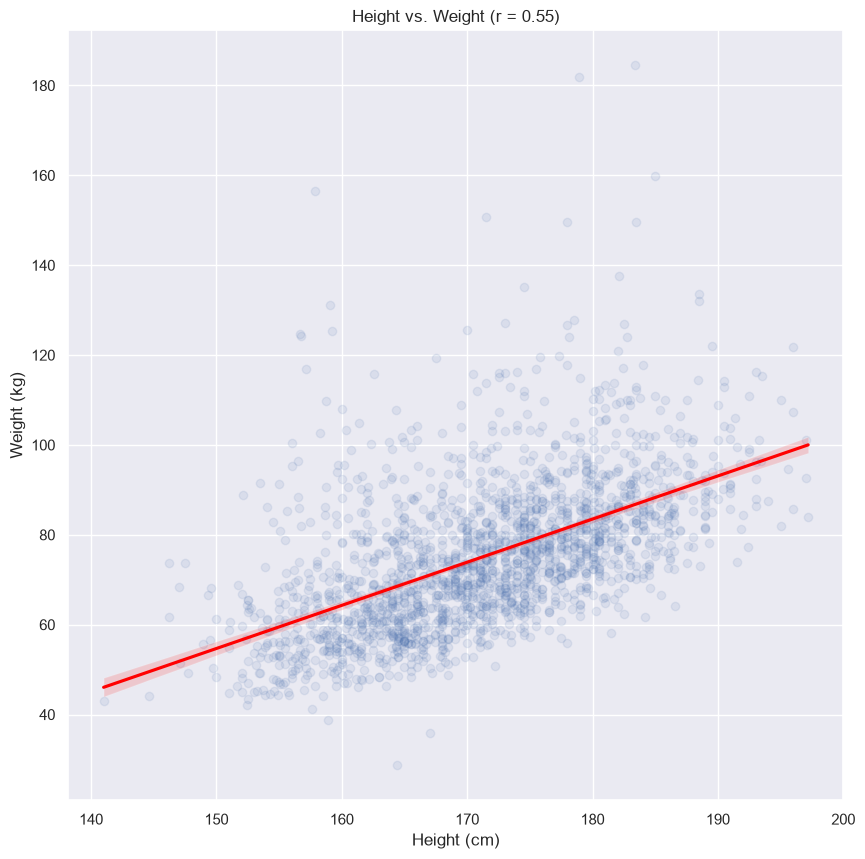

In [73]:
# Scatterplot with a best-fit line. Low alpha (transparency) reduces overplotting.
sns.regplot(data=df, x='height_cm', y='weight_kg',
            scatter_kws={'alpha': 0.1}, line_kws={'color': 'red'})
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.title(f'Height vs. Weight (r = {r:.2f})')
plt.show()

**Interpretation** r is about 0.55, a *strong* positive correlation. Taller people tend to weigh more. The p-value is tiny, so this is very unlikely to be chance.

Notice how much the points still scatter around the line. Height tells us *something* about weight, but not everything.

### From Correlation to Prediction

The red line above is a simple **linear regression** model. It lets us actually *predict* a number: given someone's height, estimate their weight.

A useful fact: **r²** is the share of the variation in weight that height explains.

In [74]:
# Fit a straight line: weight = slope * height + intercept
slope, intercept = np.polyfit(df['height_cm'], df['weight_kg'], 1)
print(f"weight_kg = {slope:.2f} * height_cm - {abs(intercept):.1f}")

# Use the line to predict
for h in [160, 175, 190]:
    print(f"Predicted weight at {h} cm: {slope * h + intercept:.1f} kg")

print(f"\nr squared = {r**2:.2f}, so height explains about {r**2:.0%} of the variation in weight")

weight_kg = 0.96 * height_cm - 89.3
Predicted weight at 160 cm: 64.3 kg
Predicted weight at 175 cm: 78.7 kg
Predicted weight at 190 cm: 93.1 kg

r squared = 0.30, so height explains about 30% of the variation in weight


We'll build much better prediction models in later modules. For now, the key idea: the stronger the correlation, the better one variable can predict the other.

## Many Variables at Once

### Pairplot

A pairplot draws a scatterplot for every pair of columns. The diagonal shows a histogram of each column. Look for patterns that form a tight line (strong correlation) versus a shapeless cloud (weak correlation).

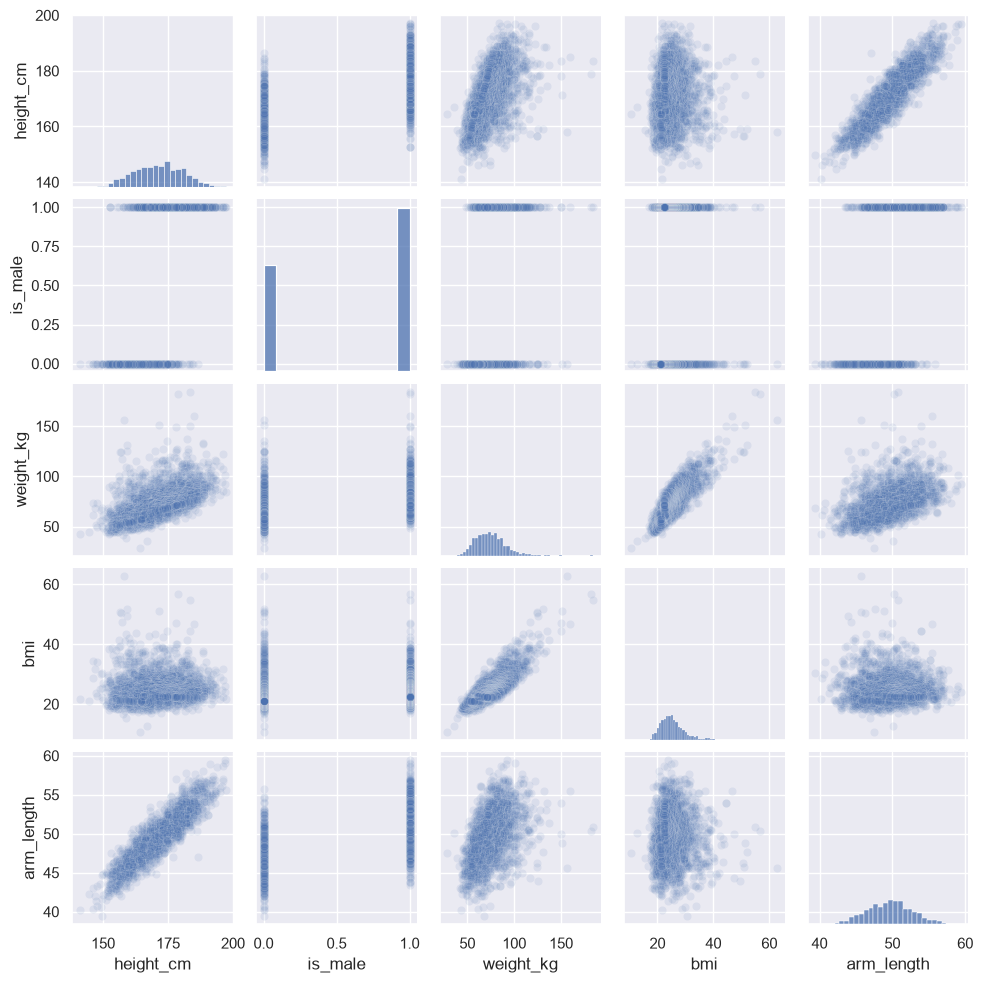

In [75]:
# Lower alpha to 0.1 to reduce overplotting. height sets the size of each small plot.
sns.pairplot(df, diag_kind='hist', height=2, plot_kws={'alpha': 0.1})
plt.show()

### Correlation Heatmap

A heatmap shows the r value for every pair, colored from blue (negative) to red (positive). The diagonal is always 1, because every column is perfectly correlated with itself.

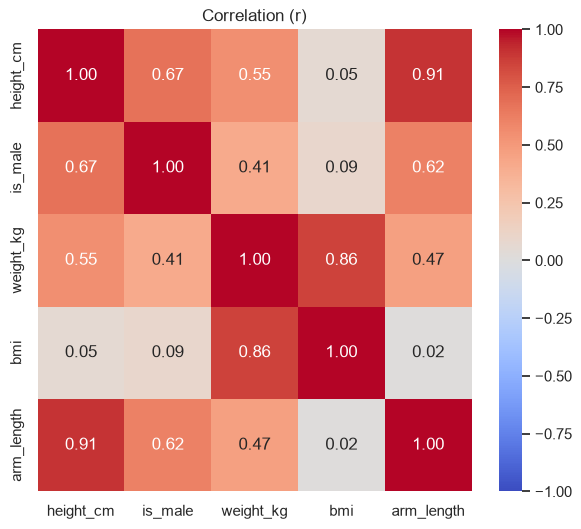

In [76]:
corr_matrix = df.corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation (r)')
plt.show()

In [77]:
# P-value for each pair of columns (diagonal left blank)
cols = df.columns
p_values = pd.DataFrame(index=cols, columns=cols, dtype=float)
for a in cols:
    for b in cols:
        if a != b:
            p_values.loc[a, b] = stats.pearsonr(df[a], df[b])[1]

# round values to 3 decimal places for easier reading
p_values = p_values.round(3)

p_values.head()

,height_cm,is_male,weight_kg,bmi,arm_length
height_cm,NaN,0.0,0.0,0.014,0.000
is_male,0.000,NaN,0.0,0.000,0.000
weight_kg,0.000,0.0,NaN,0.000,0.000
bmi,0.014,0.0,0.0,NaN,0.497
arm_length,0.000,0.0,0.0,0.497,NaN


## Significant but Meaningless

Look at **height_cm vs. bmi**
- r ≈ 0.06 (negligible)
- p ≈ 0.01 (statistically significant!)

How can both be true? With about 2,000 people, even a tiny correlation is unlikely to be *exactly* zero, so it passes the p-value test. But r = 0.06 means height explains well under 1% of the variation in BMI. It's useless for prediction.

**Lesson** A p-value tells you whether a correlation is probably real, not whether it matters. Always check the strength (r) too.

Why is BMI almost unrelated to height? BMI divides weight by height squared. It was *designed* to remove the effect of height.

## Correlation vs. Causation in This Data

**arm_length vs. weight_kg** has r ≈ 0.47, a moderate correlation. Does having longer arms make you heavier?

No. Both are driven by a third variable: **height**. Taller people have longer arms *and* tend to weigh more. Height is a *confounder*.

Similarly, **weight_kg vs. bmi** (r ≈ 0.86) is high because BMI is *calculated from* weight. A strong correlation can be built into how a variable is defined.

## Your Turn

1. Which pair of variables (other than a column with itself) has the strongest correlation? Why would you expect that?
2. Find the pair with the highest p-value. Is it statistically significant? Is it strong?
3. `is_male` is correlated with height (r ≈ 0.67). Does being male *cause* height? What else could explain this?
4. Pick a pair with a moderate correlation and suggest a possible confounder.

## Key Terms

- **Continuous variable**: A numeric variable that can take any value in a range, such as height or weight
- **Correlation (Pearson's r)**: A number from -1 to +1 measuring the strength and direction of a linear relationship
- **Positive correlation**: As one variable goes up, the other tends to go up
- **Negative correlation**: As one variable goes up, the other tends to go down
- **Strength (|r|)**: The absolute value of r; -0.6 and +0.6 are equally strong
- **Outlier**: An unusual point that can push r up or down a lot
- **Null hypothesis**: The assumption that there is no correlation in the population (r = 0)
- **p-value**: The probability of seeing a correlation at least this strong if the null hypothesis were true
- **Statistically significant**: A p-value at or below 0.05, meaning the result would be rare by chance alone
- **Linear regression**: A best-fit straight line used to predict one number from another
- **r²**: The share of the variation in one variable explained by the other
- **Pairplot**: A grid of scatterplots for every pair of columns, with histograms on the diagonal
- **Correlation heatmap**: A colored grid showing r for every pair of columns
- **Confounder**: A third variable that drives both variables, creating a correlation without causation
- **Spurious correlation**: A correlation that arises from coincidence or a confounder rather than a real link


## Practice Questions

1. What does Pearson's r measure?
   - The strength and direction of a linear relationship between two continuous variables
   - Whether one variable causes another
   - The probability that a correlation is due to chance
   - The average difference between two variables
1. What is the range of possible values for r?
   - -1 to +1
   - 0 to 1
   - 0 to 100
   - Any real number
1. Which correlation is the strongest?
   - r = -0.8
   - r = 0.5
   - r = 0.1
   - r = 0.0
1. What does r = -0.6 tell you?
   - As one variable goes up, the other tends to go down, with a strong relationship
   - There is almost no relationship
   - As one variable goes up, the other tends to go up
   - The relationship is weaker than r = +0.6
1. Using the rules of thumb in this module, how would you describe r = 0.4?
   - Moderate
   - Negligible
   - Weak
   - Strong
1. A scatterplot shows a clear U-shaped pattern, but r is close to 0. Why?
   - r only measures straight-line relationships
   - The sample is too small
   - The p-value is too high
   - U-shaped data always has a negative correlation
1. What effect can a few outliers have on r?
   - They can push r up or down a lot
   - None, since r ignores extreme values
   - They always make r closer to 0
   - They always make r closer to 1
1. What is the null hypothesis when testing a correlation?
   - There is no correlation in the population (r = 0)
   - There is a perfect correlation (r = 1)
   - One variable causes the other
   - The sample is representative of the population
1. What does the p-value represent?
   - The probability of seeing a correlation at least this strong if there were no real relationship
   - The probability that the correlation is strong
   - The share of variation explained by the model
   - The probability that one variable causes the other
1. Which p-value is conventionally called statistically significant?
   - 0.05
   - 0.20
   - 0.50
   - 0.90
1. Strength (r) and statistical significance (p-value) are:
   - Different things; a correlation can be significant but weak
   - The same thing measured two ways
   - Always in agreement: strong means significant and weak means not significant
   - Only meaningful when r is negative
1. Why can a tiny correlation like r = 0.06 still be statistically significant?
   - With a large sample, even a small correlation is unlikely to be exactly zero
   - Because small correlations are always significant
   - Because the p-value measures strength
   - Because BMI is calculated from height
1. Height and weight have r ≈ 0.55 and a tiny p-value. What is the best interpretation?
   - A strong positive relationship that is very unlikely to be due to chance
   - Height causes weight
   - Height perfectly predicts weight
   - A weak relationship that is probably due to chance
1. What does the best-fit line from linear regression let you do?
   - Predict one number from another, such as weight from height
   - Prove that one variable causes the other
   - Calculate the p-value
   - Remove outliers from the data
1. What does a pairplot show?
   - A scatterplot for every pair of columns, with histograms on the diagonal
   - Only the correlation values as numbers
   - A single best-fit line
   - The p-value for every pair
1. Why is the diagonal of a correlation heatmap always 1?
   - Every column is perfectly correlated with itself
   - The diagonal shows the strongest pair in the data
   - The heatmap rounds all values up
   - The diagonal shows the p-values
1. Arm length and weight are correlated (r ≈ 0.47). What is the best explanation?
   - Height is a confounder that drives both
   - Longer arms cause people to weigh more
   - Heavier people grow longer arms
   - The correlation is a coincidence with no explanation
1. Why is weight strongly correlated with BMI (r ≈ 0.86)?
   - BMI is calculated from weight, so the correlation is built in
   - Heavier people are always taller
   - Weight causes BMI to change over time
   - It is a spurious correlation caused by chance
1. A study finds that ice cream sales and drowning deaths are correlated. What is the most likely explanation?
   - A confounder, such as hot weather, drives both
   - Eating ice cream causes drowning
   - Drowning causes people to buy ice cream
   - The correlation must not be statistically significant